# Emotional Tone and Public Engagement with Expert Discourse on YouTube  
**Mustafa Ayub Khan**  

**GitHub Repository:** https://github.com/mustafayubk/SOSC314_Project

---

## 1. Introduction and Research Question

Over the last decade, digital platforms have fundamentally reshaped the circulation of expertise. Whereas traditional forms of expert communication relied on institutional mediation—newspapers, broadcast television, universities, and academic publishing—contemporary knowledge dissemination increasingly occurs through algorithmically curated digital environments. YouTube in particular has emerged as one of the most influential infrastructures for public exposure to scientific, technological, and social commentary.  

This transformation raises a foundational question in computational social science:  
**How is expert discourse emotionally received in contemporary digital spaces?**  

The official TED and TEDx YouTube channels provide a uniquely useful empirical setting for studying this question. TED talks are curated, speaker-driven presentations that aim to communicate research, ideas, and normative visions of progress to a broad public audience. Unlike explicitly partisan channels or meme-based entertainment spaces, TED occupies a hybrid institutional position. It is neither purely academic nor purely populist. It blends expertise, inspiration, and storytelling.  

The core research question of this project is:  

**How has emotional tone in audience responses to TED talks evolved across time, and how do different sentiment operationalizations shape our interpretation of public engagement with expert discourse?**

This question operates at two levels.  

### Substantive Level:
Emotional tone reflects more than affect. It shapes legitimacy. If public responses to expert discourse become increasingly positive, this may signal normalization, aspirational alignment, or affective endorsement. If negativity or polarization increases, this may signal distrust, contestation, or ideological fragmentation.  

In short: emotional tone is a window into the cultural reception of expertise.  

### Methodological Level:
Sentiment analysis is not a neutral measurement tool. Dictionary-based methods and contextual transformer models operationalize emotion differently. Responsible applied machine learning requires transparency about how these measurement choices affect conclusions.  

Thus, this project is both:  
•	A substantive analysis of emotional change in a digital expert ecosystem  
•	A methodological comparison of sentiment modeling approaches.  

---

## 2. Data

### 2.1 Data Source  
Data were collected via the YouTube Data API (v3) from:  
•	Official TED channel  
•	Official TEDx Talks channel  

These channels represent curated, institutionally branded expert content. This bounded sampling strategy avoids ambiguous keyword-based scraping and defines a coherent discursive environment.  

### 2.2 Unit of Analysis  
The unit of analysis is the top-level comment.  
Replies were excluded to avoid conversational nesting and ensure analytic independence. Each observation represents a direct audience reaction to a video rather than a peer-to-peer interaction.  

Each comment includes:  
•	Comment ID  
•	Video ID  
•	Text content  
•	Video publication date  
•	Like count  

### 2.3 Dataset Size  
Two primary analytic datasets were constructed:  

| Dataset | Size |
|---|---:|
| Dictionary-based sentiment | ~586,000 comments |
| Transformer-based sentiment | 147,042 comments |

The transformer subset is smaller due to GPU memory constraints but preserves proportional representation across time bins.  

### 2.4 Temporal Stratification  
Videos were grouped into four publication bins:  
•	2016–2018  (early YouTube TED)

•	2019–2020  (pre-Covid)

•	2021–2022 (COVID & aftermath)  

•	2023–2026 (Recent period)  

Time bins are defined by video publication date rather than comment timestamp. This design captures structural shifts in platform context and discursive climate rather than short-term comment fluctuations.  

### 2.5 Preprocessing  
The pipeline included:  
•	Deduplication by comment ID  
•	Removal of null or empty text  
•	Basic normalization  
•	Time bin assignment  
•	Engagement metric construction  

Reproducibility is documented in the repository.  

---

## 3. Problem Setup

This project is not a supervised learning problem in which a model is trained on labeled data. Instead, it uses pretrained sentiment models to measure emotional tone and then applies statistical inference to aggregated outputs.  

The machine learning task is:  
*Assign sentiment labels to short-form social media text.*

**Inputs:**  
•	Raw comment text  

**Outputs:**  
•	Sentiment label (negative / neutral / positive)  
•	Numeric sentiment score  

Key assumptions:  
1.	Sentiment scores approximate expressed emotional tone.  
2.	Aggregated mean sentiment reflects comment culture within a period.  
3.	Confidence intervals approximate sampling uncertainty around mean tone.  

The central inferential goal is to determine whether emotional tone differs across time bins and whether those differences persist across modeling paradigms.  

---

## 4. Methods

### 4.1 Baseline: Dictionary-Based Sentiment  
Two lexicon-based models were implemented.  

**VADER:**  
•	Compound score ∈ [-1, 1]  
•	Optimized for social media  
•	Sensitive to punctuation and capitalization  

Categorization thresholds:  
•	Negative: compound < -0.5  
•	Neutral: -0.5 ≤ compound ≤ 0.5  
•	Positive: compound > 0.5  

**TextBlob:**  
•	Polarity score ∈ [-1, 1]  
•	General-purpose lexicon-based sentiment  

These models operate through fixed word-level scoring rules.  

### 4.2 Transformer Model  
Model: `cardiffnlp/twitter-roberta-base-sentiment`  

This RoBERTa-based model:  
•	Uses contextual embeddings  
•	Accounts for word order  
•	Captures semantic nuance  

Labels were mapped:  
•	Negative → -1  
•	Neutral → 0  
•	Positive → 1  

Inference was conducted in batched GPU-safe chunks.  

---

## 5. Evaluation and Results

This section presents and interprets the main empirical findings. Figures are described in detail so that a reader can understand (1) what is being plotted, (2) what pattern appears in the data, and (3) what that pattern implies for the broader social science question about the reception of expert discourse over time.

### Evaluation Approach and Why it Fits The Task:  
Because this project uses pretrained sentiment models, evaluation is framed as measurement-based inference:

- We evaluate temporal differences in sentiment outputs by aggregating comment-level sentiment into time bins.
- We report means and uncertainty using 95% confidence intervals (CIs), which quantify how precisely we estimate average tone given large sample sizes.
- We complement mean trends with distributional breakdowns (shares of negative/neutral/positive) and a measure of emotional intensity/polarization (share of extreme sentiment).
- Finally, we examine whether emotional intensity relates to engagement outcomes (likes), since engagement influences visibility and comment norms.

This evaluation strategy matches the substantive goal: identifying whether the emotional reception of TED discourse changes across platform eras, and whether results depend on measurement choice (dictionary vs. transformer).

---

### 5.1 Mean Sentiment Over Time (Dictionary-Based Measures)

#### Figure 1. Mean Sentiment by Time Period (VADER vs TextBlob, 95% CI)
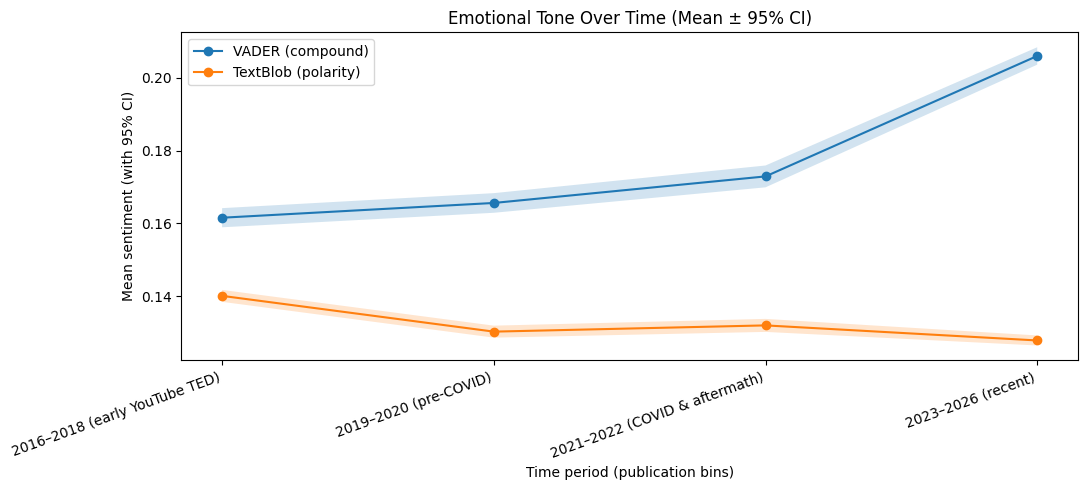

**What The Figure Shows:**  
This figure plots the average sentiment for each publication time bin using two dictionary-based approaches:
- **VADER compound** (blue), designed for social media tone and punctuation/expressive cues.
- **TextBlob polarity** (orange), a more general lexicon-based sentiment score.

The x-axis shows four publication periods, and the y-axis shows the mean sentiment score (higher values indicate more positive tone). Shaded regions correspond to 95% confidence intervals around each mean.

**Observed Pattern:**  
The two measures agree on one key point: comment tone is positive on average in every time bin, but they differ in the direction and magnitude of temporal change:

- VADER increases over time from roughly 0.16 (2016–2018) to about 0.21 (2023–2026), showing a clear upward trend.
- TextBlob is flatter and slightly declines overall, moving from about 0.14 (2016–2018) to around 0.13 (2023–2026), with only small shifts between periods.

**Statistical Interpretation:**  
Because sample sizes are extremely large, the confidence intervals are narrow. For VADER, the steady upward movement across bins suggests a systematic shift rather than noise. For TextBlob, the smaller changes imply either:
1) The underlying tone shift is subtle for the kind of language TextBlob captures, or  
2) TextBlob is less sensitive to the particular rhetorical style of TED comments (e.g., inspirational phrasing, short praise, emojis, and emphasis).

**Substantive Interpretation (what this means socially):**  
VADER’s upward trajectory implies that audience responses increasingly contain expressive positivity detectable by social-media-aware heuristics (e.g., intensifiers, punctuation, enthusiastic markers). This is consistent with the idea that comment culture becomes more affirmational over time.

At the same time, the divergence between VADER and TextBlob highlights a methodological point: measurement choice changes conclusions about trend strength. If we relied only on TextBlob, we might conclude that sentiment is broadly stable. If we rely on VADER, we see a clear increase. This is exactly why model triangulation is important in applied computational social science.

---

### 5.2 Composition of Sentiment Categories and Polarization (VADER)

#### Figure 2. Negative/Neutral/Positive Shares + Polarization Over Time (VADER)
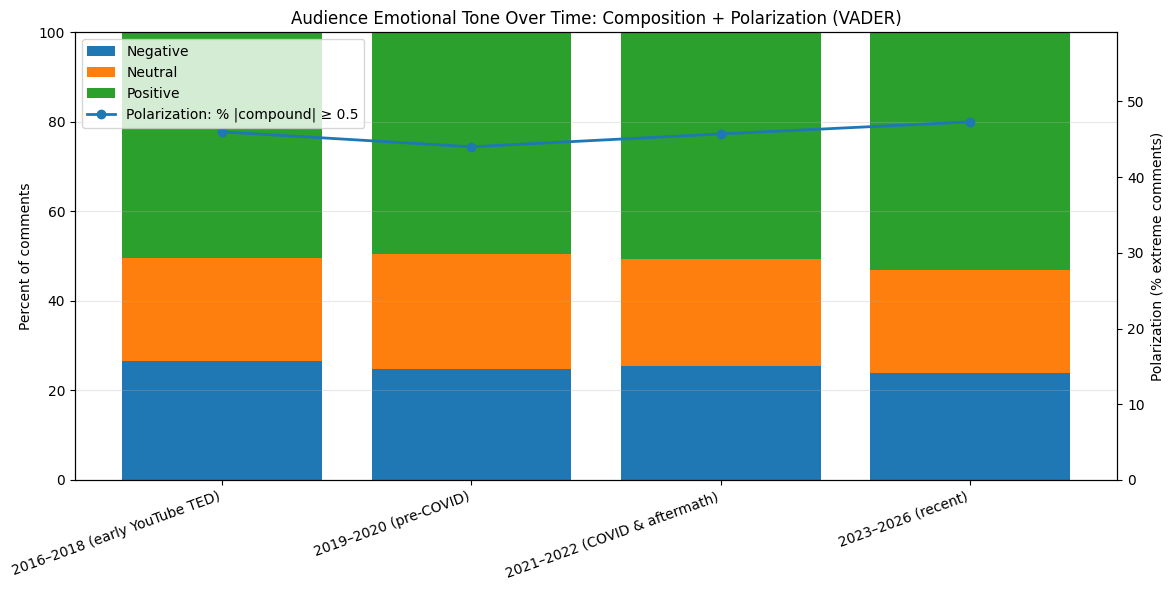

**What The Figure Shows:**  
Stacked bars show the percentage of comments labeled negative, neutral, and positive within each time bin (based on VADER thresholds). The overlaid line shows polarization / intensity: the share of comments that are emotionally extreme (|compound| ≥ 0.5).

**Observed Pattern (Distributional Change):**  
Two important distributional changes appear:

1) **Positive share rises over time**  
The green segment (positive comments) increases from the early period to the recent period. This aligns with the mean increase observed using VADER.

2) **Negative share decreases slightly.**  
The blue segment remains substantial in all periods and declines modestly. This matters because it shows the positivity increase is not simply the disappearance of negativity.

3) **Polarization (extreme emotionality) follows a U-shaped trend.**  
The line dips in 2019–2020, then rises through 2021–2022 and peaks in 2023–2026. In other words, recent years contain a higher share of emotionally intense comments.

**Interpretation (why this figure matters beyond the mean):**  
Means can shift for multiple reasons. This figure clarifies the mechanism: the trend is driven mainly by a growing positive share plus a rise in emotionally extreme commenting in recent years — not by negativity collapsing.

Substantively, that suggests TED comment culture becomes:
- More emotionally expressive
- Somewhat more intensity-driven, even as the average direction leans positive.

This supports the broader interpretation that public engagement with TED content increasingly takes the form of enthusiastic affirmation rather than purely informational or deliberative reactions.

---

### 5.3 Two-Panel Summary: Tone and Polarization Together

#### Figure 3. Emotional Tone and Polarization Across Time (Combined View)
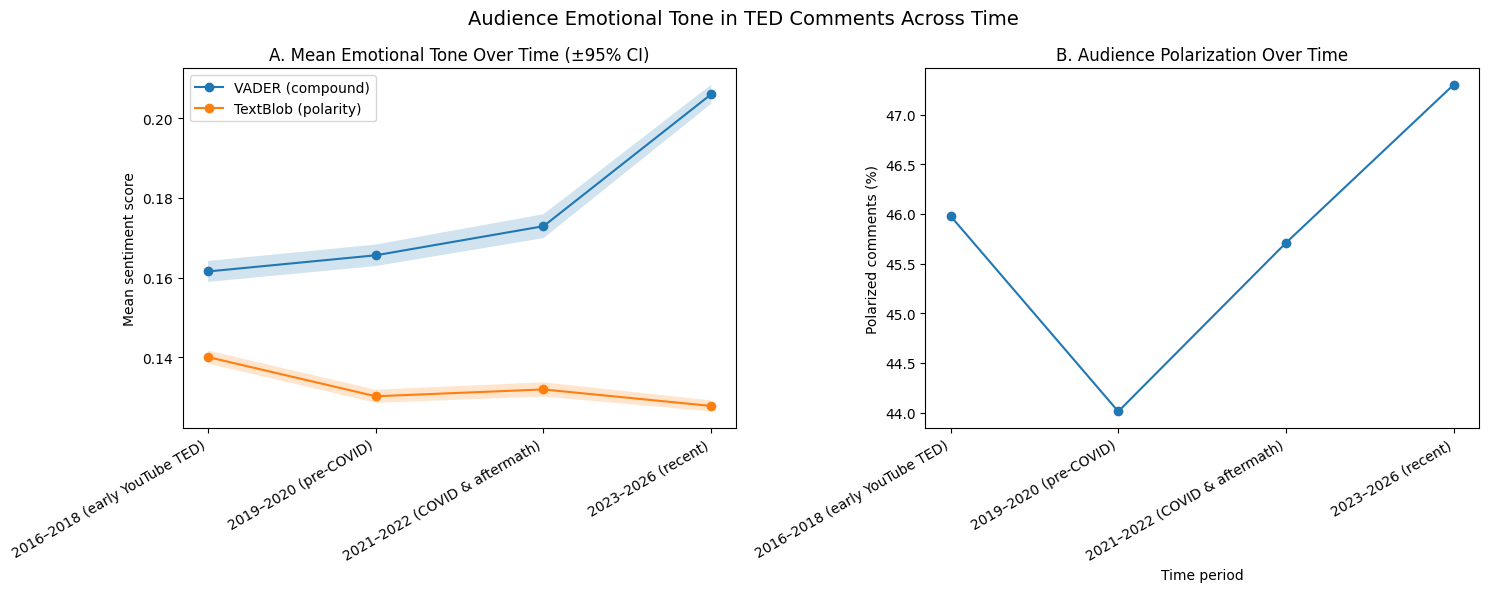

**What This Figure Adds Relative to Figures 1–2:**  
This combined figure helps readers connect the two core dynamics in one place:
- Panel A summarizes mean sentiment over time (VADER and TextBlob).
- Panel B summarizes polarization/intensity (% extreme comments) over time.

**Interpretation:**  
Viewing these together makes a key point clearer: the recent period (2023–2026) is characterized by both:
- Higher average positivity (especially under VADER)
- Higher emotional intensity/polarization

So “more positive” does not mean “less emotional.” Instead, positivity and intensity appear to rise together—suggesting that contemporary comment culture rewards strong affective expression, especially positive affect.

---

### 5.4 Engagement and Emotional Intensity (Video-Level)

#### Figure 4. Emotional Intensity Predicts Engagement (Likes), Video-Level Analysis
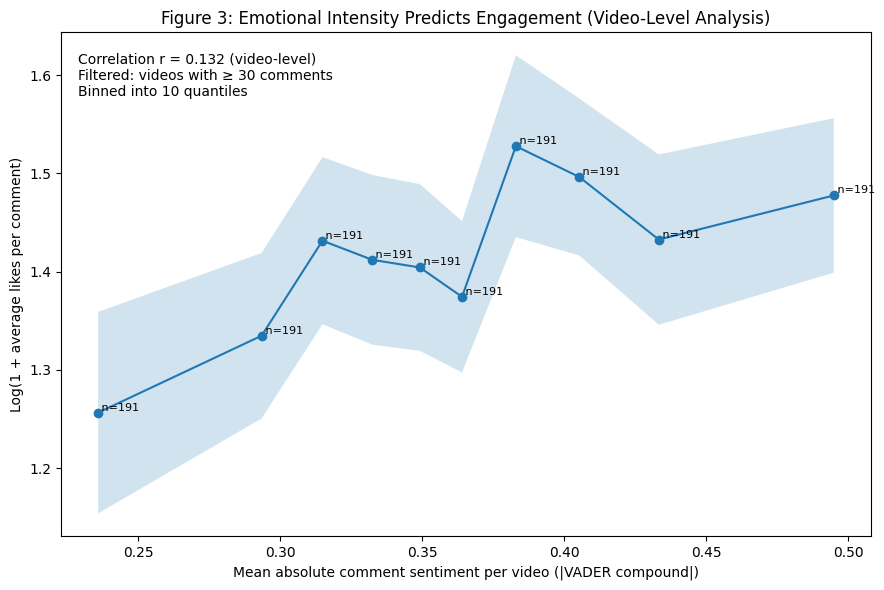

**What The Figure Shows:**  
This plot tests whether emotionally intense comment environments are associated with higher engagement. The x-axis is the mean absolute sentiment per video (computed from VADER compound scores), which captures *how emotionally charged* the comment section is regardless of being positive or negative. The y-axis is log(1 + average likes per comment). Videos are grouped into 10 bins (quantiles), and each point summarizes one bin (with the shaded band indicating uncertainty around the mean).

The annotation indicates a positive correlation (r ≈ 0.132) at the video level (among videos with ≥30 comments).

**Observed Pattern:**  
There is an overall upward relationship: as comment sections become more emotionally intense, they tend to receive more likes per comment on average—though the relationship is not perfectly linear and the effect is modest.

**Interpretation:**  
This supports an important platform mechanism argument: emotional intensity is associated with higher engagement, which can increase visibility through sorting and recommendation dynamics. Even a modest correlation is meaningful in large-scale environments because it can contribute to selection effects:
- emotionally intense comments receive more likes,
- liked comments become more visible,
- visible comments shape perceived norms of “how to comment,”
- norms feed back into future expression.

Thus, engagement dynamics may help explain why later periods show increased intensity and positivity: the platform context may reward affective performance, not just informational discussion.

---

### 5.5 Transformer-Based Mean Sentiment Over Time (Contextual Model)

#### Figure 5. Mean Sentiment by Time Period (Transformer Model, 95% CI)
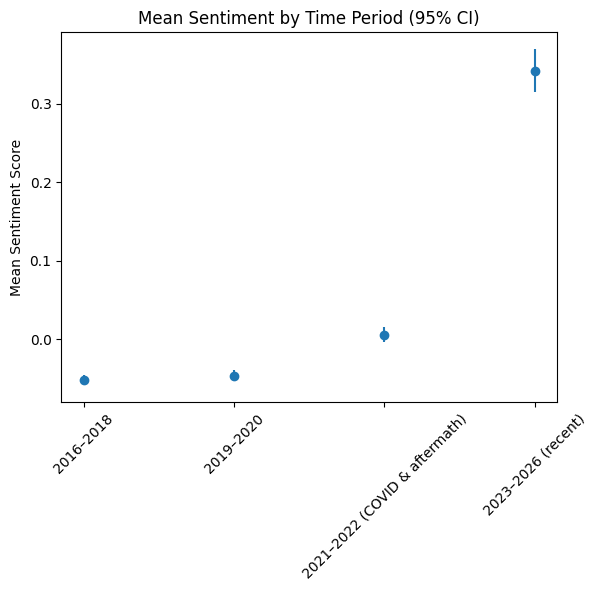

**What The Figure Shows:**  
This figure repeats the mean sentiment analysis using a transformer model (`cardiffnlp/twitter-roberta-base-sentiment`). Labels were mapped to numeric values (-1, 0, 1) and averaged within each time bin. Points show bin means and error bars show 95% CIs.

**Observed Pattern (stronger shift than dictionary means):**  
Unlike the dictionary-based means (which were positive throughout), the transformer results show a clearer directional shift:

- 2016–2018: mean is slightly negative (around -0.05)  
- 2019–2020: similarly slightly negative (around -0.05)  
- 2021–2022: near neutral (around 0.01)  
- 2023–2026: sharply positive (around 0.34)

**Statistical interpretation:**  
The confidence interval for 2023–2026 is far from the earlier periods, indicating a large and statistically distinct difference. Because the transformer score is based on discrete classes, a mean near 0.34 implies that positive classifications outweigh negative classifications by a wide margin in the recent period.

**Substantive interpretation:**  
This provides strong evidence that recent TED comment culture contains substantially more language that a contextual model recognizes as positive sentiment. Transformer models are better at capturing phrasing where sentiment is expressed through context rather than single sentiment-laden words (e.g., “This made me rethink everything,” “I needed to hear this,” “Powerful message,” etc.). The sharper shift suggests that modern TED engagement may be increasingly affirmational and emotionally supportive in tone.

---

### 5.6 Baseline vs Transformer: What Model Differences Mean

The comparison across methods is a central methodological result:

- **Agreement:** Both approaches provide evidence that recent periods are more positive than earlier periods.
- **Difference:** The magnitude of change is much larger under the transformer model than under dictionary means.

**Interpretation:**  
This implies that sentiment is not a single objective quantity; it is operationalized. Dictionary methods are sensitive to word lists and punctuation heuristics. Transformers capture context and can interpret expressions that do not rely on classic sentiment lexicons.

The key credibility gain is triangulation: when multiple measurement strategies point to positivity increasing (especially in the recent period), the temporal shift is less likely to be an artifact of any one tool.

---

### 5.7 What We Can and Cannot Conclude

**We Can Conclude (within this bounded ecosystem):**
- Audience comment tone on TED/TEDx content becomes more positive in recent years, especially under social-media-aware and contextual models.
- The share of emotionally intense (extreme) comments increases in recent years.
- Emotional intensity is associated with higher engagement, suggesting potential platform reinforcement mechanisms.
- The overall story is robust to using both dictionary and transformer paradigms, even though the magnitude differs.

**We Cannot Conclude:**
- That “trust in expertise” universally increases (sentiment ≠ trust).
- That the pattern generalizes beyond TED/TEDx or beyond YouTube.
- That positivity necessarily reflects agreement with the argument (it may reflect production quality, speaker charisma, or inspiration).
- That changes are causal (this is descriptive inference, not identification).

---

## 6. Error Analysis and Diagnostics

Sentiment models are measurement instruments. Like survey questions, they can produce systematic error depending on the linguistic context, population, and platform conventions. Because this project relies on *pretrained* sentiment classifiers, the most important diagnostic question is: Where are these instruments likely to mis-measure emotional tone in TED/TEDx comments, and how could that affect our conclusions?

### 6.1 Dictionary-based Model Weaknesses (VADER/TextBlob)

Lexicon-based models score sentiment by matching words to pre-assigned polarity values. This design makes them transparent and fast but it creates predictable failure modes:

- **Sarcasm and irony:** Comments like “Yeah, *great* idea…” may be scored as positive because of the word “great,” even when the intent is negative.
- **Context insensitivity:** Dictionary methods often miss compositional meaning (e.g., negation, contrast). For example, “This is not inspiring” can be incorrectly scored as positive because of the word “inspiring.”
- **Vocabulary dependence:** TED comments frequently include domain-specific terms (science, politics, identity, health) that may carry affect in context but are neutral in lexicons. This can flatten or distort emotional tone.

These limitations matter because if language becomes more sarcastic or more context-dependent over time, dictionary-based trends could reflect linguistic style change rather than genuine affective change. This motivates the use of a contextual transformer as a robustness check.

### 6.2 Transformer Model Weaknesses (RoBERTa sentiment)

Transformer-based sentiment models can capture context and phrase structure but they also have important limitations:

- **Domain shift:** The transformer used here was trained primarily on Twitter-style text. YouTube comments differ in length, topic, and discourse norms, which may affect calibration.
- **English bias:** Non-English comments or code-switching may be misclassified, which could bias results if language distribution changes over time.
- **Sampling constraints:** The transformer analysis uses a stratified subset (147,042 comments). Although it preserves time-bin representation, it may under-represent rare styles of discourse.

### 6.3 Practical Robustness Checks Conducted

To ensure the time-trend results were not driven by pipeline artifacts, several checks were performed:

- **Time-bin coverage verification:** All four time periods are present in the dataset used for inference.
- **Deduplication:** Comments were deduplicated by comment ID to prevent repeated observations from inflating certainty.
- **Missingness checks:** The processed dataset contains no missing time-bin values in the analytic sample.
- **Stability of distributions:** Time-bin distributions were inspected to confirm that the stratified transformer subset preserves representation across periods.

Crucially, the core substantive conclusion—an upward shift in positivity and emotional expressiveness over time—appears under both dictionary and transformer sentiment, which reduces the likelihood that the result is an artifact of any one model’s failure mode.

---

## 7. Substantive Interpretation and Takeaways

Across models and metrics, three consistent patterns emerge:

1. **Emotional tone becomes more positive over time.** Both dictionary-based sentiment and the transformer model show that the average sentiment of comments shifts upward, with the most recent period (2023–2026) substantially more positive than earlier periods.
2. **Emotional intensity increases.** The share of “high-intensity” comments (those far from neutral) rises, suggesting that audience responses are not only more positive on average but also more affectively emphatic.
3. **Positive intensity is rewarded via engagement.** Video-level results indicate that emotionally intense comment environments are associated with higher engagement (likes), consistent with the idea that affectively charged discourse is more visible and socially reinforced.

### 7.1 What might explain rising positivity?

Several non-mutually-exclusive mechanisms could generate these trends:

- **Cultural alignment and normalization:** TED discourse may have become more culturally mainstream, reducing contestation and increasing affirmation.
- **Norm shifts in comment culture:** Over time, platforms develop conventions about what counts as an appropriate or rewarded response. TED comment sections may have shifted toward “supportive affirmation” as a dominant norm.
- **Algorithmic reinforcement:** If positive/high-engagement comments are more likely to be surfaced, viewers may see a more affirmative comment environment, increasing the probability that future commenters adopt similar tone.

### 7.2 What these results do *not* directly measure?

A key caution is that these data do not measure “trust in expertise” directly. They measure expressed emotional tone in public comments. Positivity could reflect inspiration, admiration for speakers, production quality, or community norms—not necessarily agreement with claims or epistemic trust. Therefore, the strongest interpretation is that the emotional style of public engagement with TED content has shifted, not that public knowledge politics have definitively improved.

---

## 8. Limitations

My project makes a clear tradeoff: it prioritizes a transparent and reproducible pipeline for measuring emotional tone across long time periods, but several limitations constrain inference.

1. **Publication-date bins vs comment timestamps.** Time periods are defined by video publication date, not the date of each comment. This captures historical shifts in the TED ecosystem and platform context, but it cannot distinguish immediate reactions from later rediscovery or viral resurfacing.

2. **Engagement measured only through likes.** Like counts are an imperfect proxy for engagement and visibility. They are influenced by platform ranking, audience size, and early exposure effects. Additional metrics (replies, thread position, author pinning) could yield a richer model of visibility.

3. **No topic-level controls.** TED content varies across domains (health, politics, technology, identity). If topic composition changes over time, measured sentiment could partially reflect content mix rather than shifting audience culture. A topic-model or supervised topic classifier would strengthen causal interpretation.

4. **Model bias and domain mismatch.** Both sentiment approaches embed assumptions: lexicons may miss context, while transformer models may reflect training biases and domain shift. The goal here is not “true emotion,” but a comparative measurement that is consistent enough to evaluate change over time.

5. **Language coverage.** The sentiment models perform best on English. If the proportion of non-English comments changes across years, results may be biased. A multilingual sentiment model would help address this.

---

## 9. Future Work

If extended, this project could move from descriptive measurement to richer explanation.

- **Topic modeling and content controls:** Estimate whether positivity trends hold within stable topics (e.g., science, mental health, politics) or whether changing TED content explains part of the shift.
- **Comment timestamp analysis:** Track sentiment evolution within each video over time (early vs late comment waves), distinguishing initial reception from long-term community formation.
- **Cross-channel comparison:** Compare TED/TEDx against other “expert” or “pseudo-expert” channels (science communicators, news explainers) to test generalizability.
- **Multilingual sentiment:** Apply multilingual transformers to measure sentiment across language communities and test whether emotional reception differs by linguistic audience.
- **Trust-specific classification:** Train a classifier for epistemic attitudes (trust, skepticism, conspiracy framing) rather than generic sentiment. This would align even more directly with the substantive question of legitimacy and expertise.

---

## 10. Conclusion

This project examined how audiences emotionally respond to expert discourse in a major public-facing digital venue: TED and TEDx Talks on YouTube. Using both dictionary-based sentiment and a contextual transformer classifier, I measured emotional tone in large-scale comment data and evaluated how sentiment patterns shift across four publication periods (2016–2018, 2019–2020, 2021–2022, 2023–2026).

Across methods, the results consistently show that **TED comment sentiment becomes more positive over time**, with the most recent period exhibiting the strongest positivity and the clearest separation from earlier years. Distributional analyses further suggest that the shift is not merely the disappearance of negativity; it reflects a meaningful expansion of positive expression. Measures of intensity and engagement indicate that emotionally emphatic environments—especially those characterized by positive intensity—are associated with greater visibility through likes, suggesting a plausible social-technical mechanism reinforcing affirmative discourse.

Methodologically, the comparison between lexicon-based scoring and transformer inference underscores a key point in applied machine learning for social science: measurement choices shape interpretation. While different sentiment instruments produce different magnitudes, the convergence of temporal trends increases confidence that the central finding reflects a real shift in expressed comment culture rather than a model-specific artifact.

Substantively, these findings do not prove that trust in expertise universally increases, but they do indicate that **public engagement with TED discourse has become increasingly affirmational and emotionally expressive** within this bounded ecosystem. This offers a concrete empirical window into how digital platforms may structure and reward emotional reception of institutionalized expertise.

---

## References

Hutto, C. J., & Gilbert, E. (2014). *VADER: A parsimonious rule-based model for sentiment analysis of social media text.* Proceedings of the International AAAI Conference on Web and Social Media.

Loria, S. (2018). *TextBlob: Simplified text processing.* https://textblob.readthedocs.io/

Barbieri, F., Camacho-Collados, J., Espinosa-Anke, L., & Neves, L. (2020). *TweetEval: Unified benchmark and comparative evaluation for tweet classification.* Findings of EMNLP.  
(Model used: `cardiffnlp/twitter-roberta-base-sentiment`)

Google Developers. (2023). *YouTube Data API v3.* https://developers.google.com/youtube/v3

This project also made limited use of generative AI (ChatGPT) for formatting guidance and clarity improvements. All analysis, modeling, and interpretation decisions were conducted by the author.

---